# Chapter 15. 양자 베이지안 추론(Quantum Bayesian Inference)

## 개요(Overview)

이 노트북은 `qiskit-machine-learning`에서 제공하는 양자 베이지안 추론(Quantum Bayesian Inference, QBI) 구현을 시연한다. 양자 베이지안 추론은 양자 회로를 사용하여 베이지안 네트워크(Bayesian Network)의 확률적 추론을 수행하는 방법이다. 기각 샘플링(Rejection Sampling)과 추론(Inference) 기법을 통해 조건부 확률(Conditional Probability)을 계산한다.

## 1. 소개(Introduction)

### 1.1. 양자 vs 고전 베이지안 추론(Quantum vs. Classical Bayesian Inference)

베이지안 네트워크(Bayesian Networks) 또는 신뢰 네트워크(Belief Networks)는 변수들 간의 확률적 관계를 그래프 형태로 나타내는 모델이다. 각 노드(Node)는 확률 변수(Random Variable)를 나타내며, 간선(Edge)은 조건부 의존성(Conditional Dependency)을 나타낸다.

양자 베이지안 추론은 양자 중첩(Superposition)과 양자 병렬성(Quantum Parallelism)을 활용하여 고전적 방법보다 효율적으로 베이지안 네트워크의 추론을 수행할 수 있다. 양자 회로에서 각 큐비트(Qubit)는 베이지안 네트워크의 확률 변수를 나타내며, 조건부 확률 테이블(Conditional Probability Table, CPT)은 제어 회전 게이트(Controlled Rotation Gate)로 인코딩된다.

## 2. QBI 인스턴스화 방법(How to Instantiate QBI)

### 2.1. 베이지안 네트워크를 위한 회전 생성(Create Rotations for the Bayesian Networks)

양자 컴퓨팅에서 Y축 회전 행렬(Rotation Matrix around Y-axis)은 $R_y(\theta)$로 표기하며, 이는 확률 분포를 큐비트 상태로 인코딩하는 데 사용된다. 확률 $p$를 인코딩하기 위해 회전 각도 $\theta = 2 \arcsin(\sqrt{p})$를 사용한다.

$$R_y(\theta) = \begin{pmatrix} \cos(\theta/2) & -\sin(\theta/2) \\ \sin(\theta/2) & \cos(\theta/2) \end{pmatrix}$$

#### 2.1.1. 두 노드 베이지안 네트워크 예제(Two Node Bayesian Network Example)

첫 번째 예제에서는 두 개의 노드로 구성된 단순한 베이지안 네트워크를 고려한다. $X$와 $Y$ 두 개의 확률 변수(Random Variable)가 있으며, $X$는 $Y$의 부모 노드(Parent Node)이다.

조건부 확률 테이블(CPT)은 다음과 같다:

- $P(X=1) = 0.2$
- $P(Y=1|X=0) = 0.3$
- $P(Y=1|X=1) = 0.55$

![두 노드 베이지안 네트워크(Two Node Bayesian Network)](../images/Two_Node_Bayesian_Network.png)

양자 회로를 위해 조건부 확률 테이블(CPT)에 해당하는 회전 각도(Rotation Angle)가 필요하다. 대응하는 회전 각도는 $\theta = 2 \arcsin(\sqrt{p})$ 공식으로 계산한다.

- $\theta_X = 2 \arcsin(\sqrt{0.2})$ : $X$의 사전 확률(Prior Probability)
- $\theta_{Y|X=0} = 2 \arcsin(\sqrt{0.3})$ : $X=0$일 때 $Y$의 조건부 확률
- $\theta_{Y|X=1} = 2 \arcsin(\sqrt{0.55})$ : $X=1$일 때 $Y$의 조건부 확률

In [1]:
# 두 노드 베이지안 네트워크의 회전 각도(Rotation Angles) 계산
# 각 조건부 확률(Conditional Probability)을 θ = 2*arcsin(√p) 공식으로 변환한다
# Include libraries
import numpy as np

# Define rotation angles
theta_X = 2 * np.arcsin(np.sqrt(0.2))
theta_Y_X = 2 * np.arcsin(np.sqrt(0.9))
theta_Y_nX = 2 * np.arcsin(np.sqrt(0.3))

#### 2.1.2. 침입 경보 예제(Burglary Alarm Example)

이제 더 복잡한 네트워크를 고려하자. 집에 경보 시스템(Alarm System)이 있고, 침입(Burglary)과 지진(Earthquake) 두 가지 이벤트에 의해 작동된다고 가정한다.

이 시나리오의 베이지안 네트워크는 다음 변수들을 포함한다:

- **침입(Burglary, B)**: 침입이 발생했는지 여부
- **지진(Earthquake, E)**: 지진이 발생했는지 여부
- **경보(Alarm, A)**: 경보가 울렸는지 여부
- **존(John, J)**: 존이 전화했는지 여부
- **메리(Mary, M)**: 메리가 전화했는지 여부

![침입 경보(Burglary Alarm)](../images/Burglary_Alarm.png)

침입 경보 베이지안 네트워크의 변수들과 조건부 확률은 다음과 같다:

- $P(B=1) = 0.001$ : 침입(Burglary) 확률은 매우 낮다
- $P(E=1) = 0.002$ : 지진(Earthquake) 확률도 매우 낮다
- $P(A=1|B=1,E=1) = 0.95$ : 침입과 지진이 동시에 발생하면 경보가 울릴 확률이 높다
- $P(A=1|B=1,E=0) = 0.94$ : 침입만 발생해도 경보가 울릴 확률이 높다
- $P(A=1|B=0,E=1) = 0.29$ : 지진만 발생하면 경보가 울릴 확률이 중간이다
- $P(A=1|B=0,E=0) = 0.001$ : 아무 일도 없으면 경보가 울릴 확률이 매우 낮다
- $P(J=1|A=1) = 0.9$ : 경보가 울리면 존(John)이 전화할 확률이 높다
- $P(J=1|A=0) = 0.05$ : 경보가 없어도 존이 전화할 확률이 약간 있다
- $P(M=1|A=1) = 0.7$ : 경보가 울리면 메리(Mary)가 전화할 확률이 높다
- $P(M=1|A=0) = 0.01$ : 경보가 없으면 메리가 전화할 확률이 매우 낮다

In [2]:
# 침입 경보(Burglary Alarm) 예제의 회전 각도 계산
# 5개 변수(B, E, A, J, M)에 대한 모든 조건부 확률을 회전 각도로 변환한다
theta_B = 2 * np.arcsin(np.sqrt(0.001))
theta_E = 2 * np.arcsin(np.sqrt(0.002))
theta_A_nBnE = 2 * np.arcsin(np.sqrt(0.001))
theta_A_nBE = 2 * np.arcsin(np.sqrt(0.29))
theta_A_BnE = 2 * np.arcsin(np.sqrt(0.94))
theta_A_BE = 2 * np.arcsin(np.sqrt(0.95))
theta_J_nA = 2 * np.arcsin(np.sqrt(0.05))
theta_J_A = 2 * np.arcsin(np.sqrt(0.9))
theta_M_nA = 2 * np.arcsin(np.sqrt(0.9))
theta_M_A = 2 * np.arcsin(np.sqrt(0.3))

### 2.2. 베이지안 네트워크를 위한 양자 회로 생성(Create a Quantum Circuit for the Bayesian Networks)

베이지안 네트워크는 양자 회로로 표현할 수 있다. 각 확률 변수(Random Variable)는 하나의 큐비트(Qubit)에 대응하며, 조건부 확률은 제어 회전 게이트(Controlled Rotation Gate)로 구현한다. 부모 노드가 없는 변수는 단순한 $R_y$ 회전으로, 부모 노드가 있는 변수는 제어-$R_y$(Controlled-$R_y$) 게이트로 인코딩한다.

#### 2.2.1 두 노드 베이지안 네트워크 예제(Two Node Bayesian Network Example)

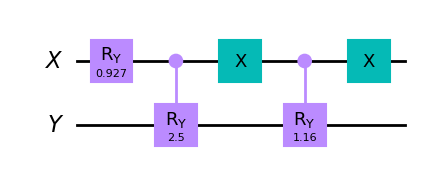

In [3]:
# 두 노드 베이지안 네트워크의 양자 회로(Quantum Circuit) 구성
# X 큐비트에 Ry 회전 적용, Y 큐비트에 제어-Ry(Controlled-Ry) 게이트 적용
from qiskit import QuantumRegister
from qiskit import QuantumCircuit

# Define quantum registers
qrX = QuantumRegister(1, name="X")
qrY = QuantumRegister(1, name="Y")
# Define a 2-qubit quantum circuit
qc_2n = QuantumCircuit(qrX, qrY, name="Bayes net small")
# Apply the R_Y_theta rotation gate on the first qubit
qc_2n.ry(theta_X, 0)
# Apply the controlled-R_Y_theta rotation gate
qc_2n.cry(theta_Y_X, control_qubit=qrX, target_qubit=qrY)
# Apply the X gate on the first qubit
qc_2n.x(0)
# Apply the controlled-R_Y_theta rotation gate
qc_2n.cry(theta_Y_nX, control_qubit=qrX, target_qubit=qrY)
# Apply another X gate on the first qubit
qc_2n.x(0)
qc_2n.draw("mpl", style="clifford", plot_barriers=False, justify="none", fold=-1)

#### 2.2.2. 침입 경보 예제(Burglary Alarm Example)

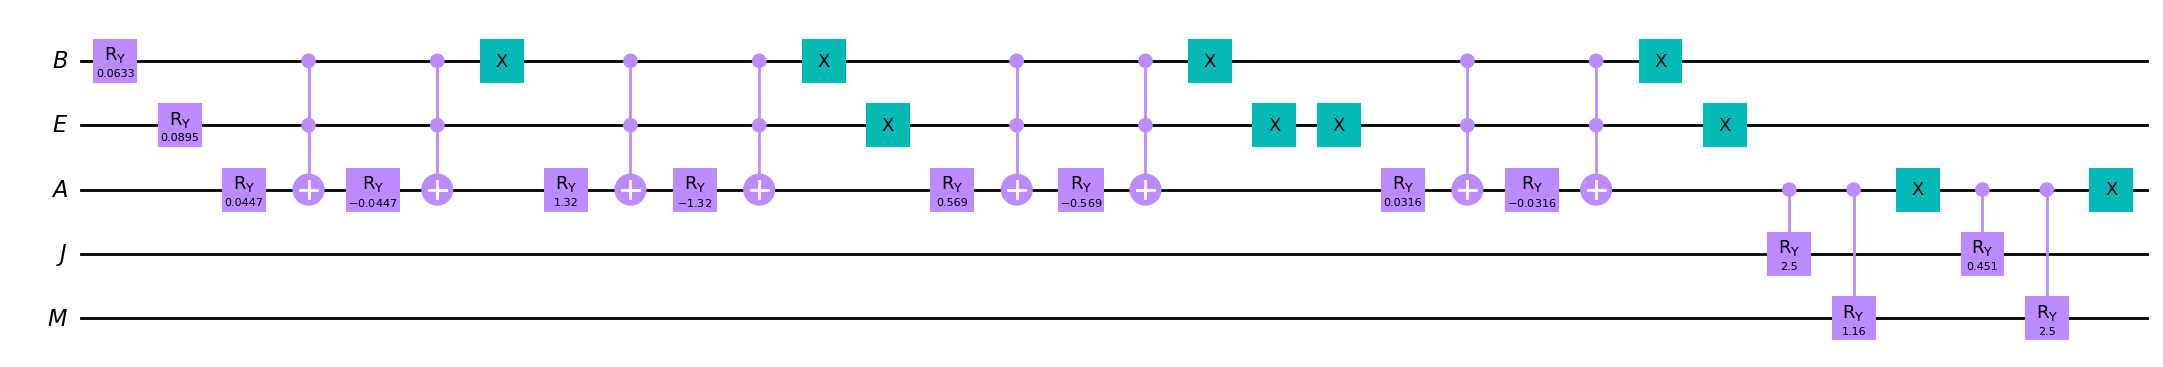

In [4]:
# 침입 경보(Burglary Alarm) 예제의 양자 회로 구성
# 5개 변수를 각각 큐비트로 표현하고, 조건부 확률을 제어 회전 게이트로 인코딩한다
# Initialize register
var = ["B", "E", "A", "J", "M"]
qr = [QuantumRegister(1, name=v) for v in var]
qc_ba = QuantumCircuit(*qr, name="State preparation")
# Specify control qubits
# P(B)
qc_ba.ry(theta_B, qr[0])
# P(E)
qc_ba.ry(theta_E, qr[1])
# P(A|B,E)
qc_ba.mcry(theta_E, [qr[0][0], qr[1][0]], qr[2])
# P(A|-B,E)
qc_ba.x(qr[0])
qc_ba.mcry(theta_A_BnE, [qr[0][0], qr[1][0]], qr[2])
qc_ba.x(qr[0])
# P(A|B,-E)
qc_ba.x(qr[1])
qc_ba.mcry(theta_A_nBE, [qr[0][0], qr[1][0]], qr[2])
qc_ba.x(qr[1])
# P(A|-B,-E)
qc_ba.x(qr[0])
qc_ba.x(qr[1])
qc_ba.mcry(theta_A_nBnE, [qr[0][0], qr[1][0]], qr[2])
qc_ba.x(qr[0])
qc_ba.x(qr[1])
# P(J|A)
qc_ba.cry(theta_J_A, qr[2], qr[3])
# P(M|A)
qc_ba.cry(theta_M_A, qr[2], qr[4])
# P(J|-A) + P(M|-A)
qc_ba.x(qr[2])
qc_ba.cry(theta_J_nA, qr[2], qr[3])
qc_ba.cry(theta_M_nA, qr[2], qr[4])
qc_ba.x(qr[2])
# Draw circuit
qc_ba.draw("mpl", style="clifford", plot_barriers=False, justify="none", fold=-1)

## 3. 기각 샘플링 실행 방법(How to Run Rejection Sampling)

기각 샘플링(Rejection Sampling)은 확률적 컴퓨팅에서 분포로부터 표본을 생성하는 기본 기법이다. 양자 회로를 여러 번 측정(Measurement)하여 표본을 생성하고, 증거 조건(Evidence Condition)을 만족하지 않는 표본을 제거(Reject)하는 방식으로 동작한다.

### 3.1. 설정(Set up)

기각 샘플링(Rejection Sampling)은 분포로부터 관측치를 생성하기 위해 확률적 컴퓨팅에서 사용되는 기본 기법이다. 양자 기각 샘플링에서는 양자 회로를 반복적으로 측정하여 증거 조건에 부합하는 표본만 선택한다.

#### 3.1.1 두 노드 베이지안 네트워크 예제(Two Node Bayesian Network Example)

$X=1$을 증거(Evidence)로 설정하여 기각 샘플링을 수행한다. 이를 통해 $X=1$이라는 조건 하에서 $Y$의 조건부 확률 분포를 추정할 수 있다.

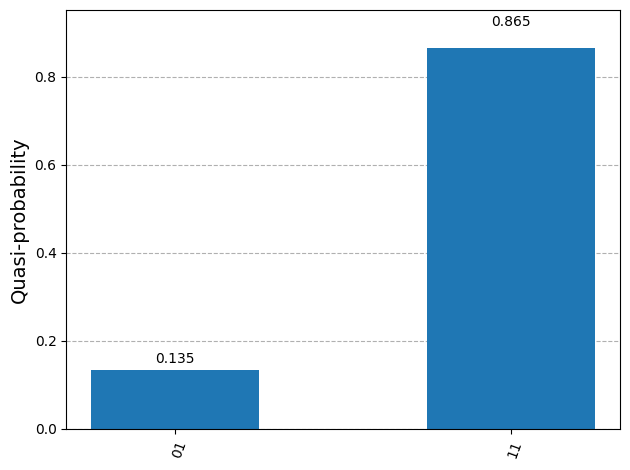

In [5]:
# QBayesian 프레임워크를 사용한 기각 샘플링(Rejection Sampling) 실행
# 증거(Evidence): X=1, 이 조건 하에서의 확률 분포를 추정한다
from qiskit_machine_learning.algorithms import QBayesian
from qiskit.visualization import plot_histogram
from qiskit.primitives import StatevectorSampler as Sampler

sampler = Sampler()
evidence = {"X": 1}
# Initialize QBayesian
qb_2n = QBayesian(circuit=qc_2n, sampler=sampler)
# Sampling
samples = qb_2n.rejection_sampling(evidence=evidence)
plot_histogram(samples)

임계값(Threshold)을 설정하여 증거를 수락하는 기준을 조절할 수 있다. 예를 들어 임계값을 0.9로 설정하면, 각 증거 큐비트가 원하는 값과 최소 90% 이상 일치해야 표본으로 수락된다. 임계값을 높이면 더 정확한 결과를 얻을 수 있지만, 더 많은 표본이 필요하다.

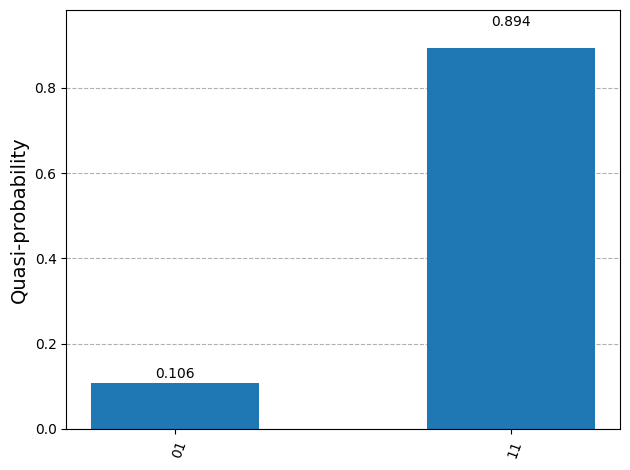

In [6]:
# 임계값(Threshold)을 0.97로 설정하여 더 엄격한 기각 샘플링 수행
# 높은 임계값은 더 정확한 결과를 제공하지만 더 많은 표본이 필요하다
# Sampling
qb_2n.threshold = 0.97
samples = qb_2n.rejection_sampling(evidence=evidence)
plot_histogram(samples)

결과를 더 나은 형식으로 출력하여 어떤 값이 어떤 변수에 해당하는지 이해할 수 있다. `format_res=True` 옵션을 사용하면 변수명과 함께 결과가 표시된다.

In [7]:
# format_res=True 옵션으로 변수명이 포함된 형식의 결과 출력
qb_2n.threshold = 0.97
samples = qb_2n.rejection_sampling(evidence=evidence, format_res=True)
print(samples)

{'P(Y=0|X=1)': 0.1015625, 'P(Y=1|X=1)': 0.8984375}


#### 3.1.2. 침입 경보 예제(Burglary Alarm Example)

더 복잡한 침입 경보(Burglary Alarm) 예제에서도 위와 동일한 단계를 따를 수 있다. 여기서는 존(John)이 전화했다는 증거($J=1$)가 주어졌을 때의 조건부 확률을 계산한다.

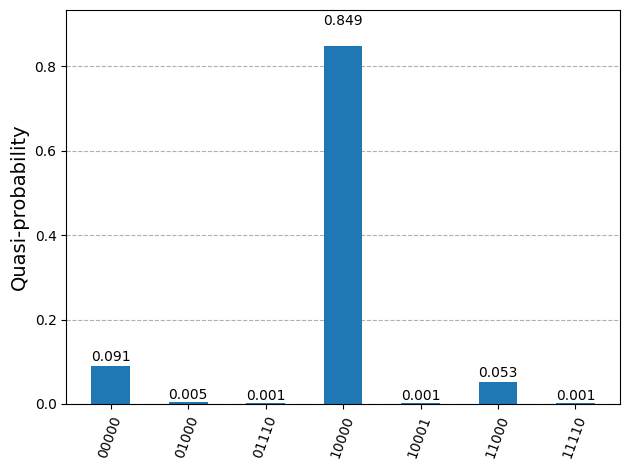

In [8]:
# 침입 경보(Burglary Alarm) 예제에 대한 양자 베이지안 추론 프레임워크 초기화 및 기각 샘플링 실행
# 존(John)이 전화했다는 증거(J=1) 하에서의 확률 분포를 추정한다
# Initialize quantum bayesian inference framework
qb_ba = QBayesian(circuit=qc_ba, sampler=sampler)
# Inference
counts = qb_ba.rejection_sampling(evidence={})
plot_histogram({c_key: c_val for c_key, c_val in counts.items() if c_val > 0.0001})

## 4. 추론 실행 방법(How to Run an Inference)

### 4.1 설정(Set Up)

양자 베이지안 추론(Quantum Bayesian Inference)은 양자 기각 샘플링(Quantum Rejection Sampling)을 기반으로 한다. 양자 기각 샘플링은 양자 역학적 특성을 활용하여 고전적 기각 샘플링보다 효율적으로 사후 확률(Posterior Probability)을 추정하는 기법이다.

`QBayesian` 클래스의 `inference` 메서드를 사용하면 질의 변수(Query Variable)에 대한 조건부 확률을 직접 계산할 수 있다.

#### 4.1. 두 노드 베이지안 네트워크 예제(Two Node Bayesian Network Example)

`QBayesian`을 사용하여 다양한 확률적 결론을 도출할 수 있다. 이 베이지안 네트워크에서 $X=1$이라는 증거(Evidence)가 주어졌을 때 $Y=0$의 확률을 계산한다.

In [9]:
# 두 노드 예제: 질의(Query) Y=0, 증거(Evidence) X=1에 대한 추론(Inference) 실행
# P(Y=0 | X=1)을 계산한다
query = {"Y": 0}
evidence = {"X": 1}
# Inference
qb_2n.inference(query=query, evidence=evidence)

0.11328125

#### 4.2. 침입 경보 예제(Burglary Alarm Example)

침입 경보 예제에서는 더 많은 선택지가 있다. 예를 들어, 존(John)이 전화했다는 증거($J=1$)가 주어졌을 때 침입(Burglary)이 발생했을 확률($P(B=1|J=1)$)을 계산할 수 있다.

In [10]:
# 침입 경보 예제: 질의(Query) B=1, 증거(Evidence) J=1에 대한 추론 실행
# 존이 전화했을 때 침입이 발생했을 확률 P(B=1|J=1)을 계산한다
query = {"B": 1}
evidence = {"J": 1}
# Inference
qb_ba.inference(query=query, evidence=evidence)

0.00390625

추론(Inference)에서도 임계값(Threshold)을 높게 설정할 수 있다. 때로는 `num_shots` 값을 높게 설정하여 결과를 개선할 수도 있다. 더 많은 샷(Shots)을 사용하면 통계적 정확도가 향상된다.

In [11]:
# 임계값(Threshold)을 0.97로 높여 더 정확한 추론 결과를 얻는다
# Inference
qb_ba.threshold = 0.97
qb_ba.inference(query=query, evidence=evidence)

0.00390625

알고리즘이 수렴(Converge)했는지 확인할 수 있다. 수렴 여부는 `converged` 속성을 통해 확인한다.

In [12]:
# 알고리즘의 수렴(Convergence) 여부를 확인한다
print("Converged: ", qb_ba.converged)

Converged:  True


In [1]:
# 튜토리얼 마직을 임포트한다
import tutorial_magics

%qiskit_version_table
%qiskit_copyright